### Solución de MDPs utilizando el método de Q-learning

In [1]:
#Ambiente de gridworld

#Definición de la clase principal
class Gridworld:
    def __init__(self, board:list[list[str]], dimensions:tuple[int,int]):
        self.nrows, self.ncols = dimensions
        self.grid = [[0 for _ in range(self.ncols)] for _ in range(self.nrows)]

        for i in range(len(board)):
            for j in range(len(board[0])):
                if board[i][j] == "#":
                    self.grid[i][j] = None
                elif board[i][j] == "S":
                    self.initial_state = (i,j)
                elif board[i][j] != " ":
                    self.grid[i][j] = int(board[i][j])
        self.state = self.initial_state

    def get_states(self) -> list[list[int]]:
        return self.grid

    def get_current_state(self) -> tuple[int, int]:
        return self.state

    def state_value(self, state:tuple[int, int]) -> float:
        return self.grid[state[0]][state[1]]

    def get_possible_actions(self, state:tuple[int,int]) -> list[str]:
        actions = ['up', 'right', 'down', 'left']
        x = state[0]
        y = state [1]
        if x == 0:
            actions.remove('up')
        elif x == 3:
            actions.remove('down')
        if y == 0:
            actions.remove('left')
        elif y == 11:
            actions.remove('right')
        return actions

    def get_action_index(self, action:str) -> int:
        actions = ['up', 'right', 'down', 'left']
        index = 0
        for a in actions:
            if action == a:
                return index
            index += 1

    def get_possible_states(self, state:tuple[int,int], action:str) -> tuple[list[float], list[float], list[tuple[int,int]]]:
        actions = self.get_possible_actions(state)
        action_index = self.get_action_index(action)
        probability = [0.1, 0.1, 0.8]
        rewards=[]
        states=[]
        for i in [-1, 1, 0]:
            action = actions[(action_index+i)%len(actions)]
            reward, new_state = self.simulate_action(state, action)
            rewards.append(reward)
            states.append(new_state)
        return probability, rewards, states

    def do_action(self, action:str) -> tuple[float, tuple[int,int]]:
        i, j = self.state
        if action == 'up' and i > 0 and self.grid[i-1][j] != None:
            i -= 1
        elif action == 'down' and i < self.nrows-1 and self.grid[i+1][j] != None:
            i += 1
        elif action == 'left' and j > 0 and self.grid[i][j-1] != None:
            j -= 1
        elif action == 'right' and j < self.ncols-1 and self.grid[i][j+1] != None:
            j += 1
        self.state = (i,j)
        reward = -1 if self.grid[i][j] == -1 else self.grid[i][j]
        return reward, self.state

    def reset(self):
        self.state = self.initial_state

    def is_terminal(self, state:tuple[int,int]=None) -> bool:
        if state == None:
            state = self.state
        return state == (3,11) or self.grid[state[0]][state[1]] == -100

In [2]:
#Ambiente general de prueba para todos los casos siguientes

board = [['-1','-1','-1','-1','-1','-1','-1','-1','-1','-1','-1','-1'],
      ['-1','-1','-1','-1','-1','-1','-1','-1','-1','-1','-1','-1'],
      ['-1','-1','-1','-1','-1','-1','-1','-1','-1','-1','-1','-1'],
      ['S','-100','-100','-100','-100','-100','-100','-100','-100','-100','-100',' ']]

gridworld = Gridworld(board, (4,12))

In [5]:
gridworld.get_possible_actions((3,0))

['up', 'right']

In [ ]:
#Agente de Q-learning

#Importe de las librerias necesarias
import random

class QLearning:
    def __init__(self, env, epsilon=0.9, gamma=0.9, alpha=0.5):
        self.env = env
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha
        self.qtable ={}

    def get_value(self, state:tuple[int,int], action:str) -> float:
        return self.qtable.get((state, action), 0.0)

    def choose_action(self, state:tuple[int,int]) -> str:
        actions = self.env.get_possible_actions(state)
        if not actions:
            return None
        if random.random() < self.epsilon:
            return random.choice(actions)
        q_values = [self.get_value(state, a) for a in actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
        return random.choice(best_actions)

    def update_values(self, state:tuple[int,int], action:str, next_state:tuple[int,int], reward:int) -> None:
        q_sa = self.get_value(state, action)
        if self.env.is_terminal(next_state):
            max_q_next = 0.0
        else:
            possible_actions = self.env.get_possible_actions(next_state)
            if possible_actions:
                q_values_next = [self.get_value(next_state, a) for a in possible_actions]
                max_q_next = max(q_values_next)
            else:
                max_q_next = 0.0
        new_q = (1 - self.alpha) * q_sa + self.alpha * (reward + self.gamma * max_q_next)
        self.qtable[(state, action)] = new_q

    def best_action(self, state:tuple[int,int]) -> str:
        actions = self.env.get_possible_actions(state)
        if not actions:
            return ""
        if actions == ['exit']:
            return 'exit'
        q_values = [self.get_value(state, a) for a in actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
        return random.choice(best_actions)

    def step(self, action:str) -> tuple[tuple[int,int],int, bool, str]:
        initial_state = self.env.get_current_state()
        reward, next_state = self.env.do_action(action)
        status = self.env.is_terminal(next_state)
        info = f"Estado inicial: {initial_state} tomando la acción: {action} -> {next_state} (recompensa {reward})"
        return [next_state, reward, status, info]

    def run(self, episodes:int) -> dict[tuple[int,str],float]:
        for episode in range(episodes):
            self.env.reset()
            state = self.env.get_current_state()
            while not self.env.is_terminal(state):
                action = self.choose_action(state)
                if action is None:
                    break
                next_state, reward, status, info = self.step(action)
                self.update_values(state, action, next_state, reward)
                state = next_state
            if episode % 100 == 0:
                if self.epsilon > 0.01:
                    self.epsilon *= 0.9
                    self.epsilon = max(self.epsilon, 0.01)
        return self.qtable

    def test_performance(self) -> tuple[dict, dict]:
        actions = {}
        values = {}
        for i in range(self.env.nrows):
            for j in range(self.env.ncols):
                    if not self.env.is_terminal((i,j)):
                        action = self.best_action((i,j))
                        actions[(i,j)] = action
                        values[(i,j)] = self.get_value((i,j), action)
        return actions, values

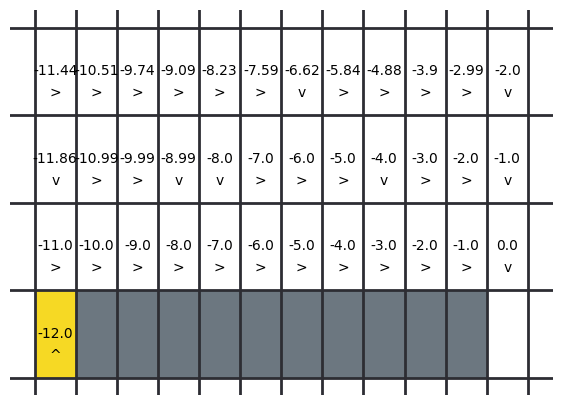

(3, 11)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import collections

a = QLearning(gridworld, 0.1, 1, 0.9)
qtable = a.run(200)

policy, values = a.test_performance()

#Función de soporte para graficar el ambiente
def draw_action(action):
    if action=='left':
        return '<'
    if action=='right':
        return '>'
    if action=='up':
        return '^'
    if action=='down':
        return 'v'
    if action=='exit':
        return 'x'

def plot_actions(env, actions, values):
    fig1 = plt.figure(figsize=(7, 5))
    ax1 = fig1.add_subplot(111)

    # Lineas
    for i in range(0, env.nrows+1):
        ax1.axhline(i , linewidth=2, color="#2D2D33")
    for i in range(env.ncols+1):
        ax1.axvline(i , linewidth=2, color="#2D2D33")

    # Amarillo - inicio
    (i,j)  = env.initial_state
    ax1.add_patch(patches.Rectangle((j, env.nrows - i -1), 1, 1, facecolor = "#F6D924"))
    for j in range(env.ncols):
        for i in range(env.nrows):
            if env.grid[i][j] == 1: # verde
                ax1.add_patch(patches.Rectangle((j,env.nrows - i -1), 1, 1, facecolor = "#68FF33"))
            if env.grid[i][j] == -100: # gris
                ax1.add_patch(patches.Rectangle((j,env.nrows - i -1), 1, 1, facecolor = "#6c7780"))
            #if env.grid[i][j] == -1: # rojo
            #    ax1.add_patch(patches.Rectangle((j,env.nrows - i -1), 1, 1, facecolor = "#cc0000"))
    for i in range(env.nrows):
        for j in range(env.ncols):
            if env.grid[i][j] == None:
                ax1.text(i+0.5, j+0.5, "", ha='center', va='center')
            else:
                if env.grid[i][j] != -100 and (i,j) != (3,11):
                    ax1.text(j+0.5, env.nrows-i-1+0.5, str(round(values[i,j],2)), ha='center', va='center')
                    text2=draw_action(actions[(i,j)])
                    ax1.text(j+0.5, env.nrows-i-1+0.25, text2, ha='center', va='center')
    plt.axis("off")
    plt.show()

plot_actions(gridworld, policy, values)
gridworld.get_current_state()